## UCI Concrete dataset

|변수명|의미|
|---|---|
|Cement|시멘트 투입량|
|BlastFurnace Slag|고로슬래그|
|Fly Ash|플라이 애시|
|Water|물|
|Superplasticizer|고성능 감수제|
|Coarse Aggregate|굵은 골재|
|Fine Aggregate|잔골재|
|Age|양생 기간 (일)|

In [1]:
import pandas as pd

df = pd.read_csv("concrete_data.csv")
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


### 1단계: 분석 환경 정의 및 자동 전처리 (`setup`)

머신러닝 학습을 시작하기 전에 데이터를 컴퓨터에게 이해하기 쉽게 설명해주는 사전 전처리 단계입니다. `setup()` 함수를 호출하면 다음과 같은 일들이 백그라운드에서 자동으로 진행됩니다.

#### 💡 `setup()` 실행 시 일어나는 일들
1. **학습/테스트 데이터 분할**: 데이터를 무작위로 섞은 후, 약 **70%는 공부용(Train)** 데이터로, **30%는 시험용(Test)** 데이터로 나눕니다.
2. **데이터 타입 자동 추론**: 각 변수가 숫자형인지, 문자/범주형인지 자동으로 인식합니다.
3. **결측치(빈칸) 처리**: 데이터에 빈칸(누락값)이 있을 경우, 기본적으로 숫자 데이터는 **평균값(Mean)**으로, 문자 데이터는 가장 빈도가 높은 **최빈값(Mode)**으로 알아서 채워 넣습니다.

#### 📊 주요 결과 표 해석 가이드

| 항목명 (Description) | 의미 | 비개발자 눈높이 설명 |
|---|---|---|
| **Session id** | 실험 고정 번호 | 나중에 동일한 데이터를 사용해 분석했을 때 항상 같은 결과를 얻기 위해 지정하는 일련번호입니다. |
| **Target** | 예측하려는 정답 | 인공지능이 맞춰야 하는 최종 결과물(콘크리트 압축 강도)입니다. |
| **Target type** | 예측 분석 종류 | 수치(예: 콘크리트 강도)를 맞추는 **회귀(Regression)** 분석 방식으로 진행된다는 뜻입니다. |
| **Original data shape** | 원본 데이터 크기 | 전체 행의 개수와 열의 개수를 뜻합니다. (예: 1030행, 9열) |
| **Transformed train set** | 공부용 데이터 크기 | 모델이 학습하는 데 사용되는 데이터셋 크기입니다. (70%) |
| **Transformed test set** | 시험용 데이터 크기 | 학습 완료 후 예측 성능을 평가하기 위한 시험 데이터셋 크기입니다. (30%) |
| **Numeric features** | 입력값(원인 변수) 개수 | 콘크리트 강도 예측에 사용되는 배합 성분(재료량, 양생 기간 등)의 개수입니다. |
| **Numeric imputation** | 빈칸 채우기 규칙 | 숫자 데이터에 빈칸이 있을 때 어떻게 메울 것인가를 결정합니다. (기본값: 평균 `mean`이며, `setup()` 내 파라미터 설정을 통해 `median`(중앙값)이나 `zero`(0)로 직접 변경할 수 있습니다.) |

*(참고: 결측치 처리 규칙을 변경하고 싶다면 `numeric_imputation='median'` 또는 `numeric_imputation='zero'`와 같이 setup() 괄호 안에 속성을 적어주면 됩니다.)*

In [2]:
# 1. PyCaret의 예측(회귀) 도구들을 모두 가져옵니다.
from pycaret.regression import *

# 2. 분석 환경을 설정합니다.
# df: 콘크리트 데이터셋
# target: 우리가 최종적으로 맞추고 싶은 정답 (콘크리트 압축 강도)
# session_id: 나중에 다시 실행해도 똑같은 결과가 나오도록 실험 번호를 고정합니다.
s = setup(data=df, target='concrete_compressive_strength', session_id=123)

,Description,Value
0,Session id,123
1,Target,concrete_compressive_strength
2,Target type,Regression
3,Original data shape,"(1030, 9)"
4,Transformed data shape,"(1030, 9)"
5,Transformed train set shape,"(721, 9)"
6,Transformed test set shape,"(309, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [3]:
# 2단계: 비교 (15개 이상 모델을 한 번에 시험 보고 1등 가리기)
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,3.2006,21.9523,4.6356,0.9215,0.1511,0.1106,0.1760
et,Extra Trees Regressor,3.2530,23.4571,4.7985,0.9166,0.1527,0.1128,0.0160
gbr,Gradient Boosting Regressor,3.7650,27.6610,5.2383,0.9007,0.1634,0.1295,0.0110
rf,Random Forest Regressor,3.6619,28.2038,5.2328,0.8993,0.1679,0.1290,0.0260
dt,Decision Tree Regressor,4.5467,43.9027,6.5348,0.8442,0.2165,0.1580,0.0030
ada,AdaBoost Regressor,6.1832,57.2779,7.5252,0.7944,0.2782,0.2605,0.0080
knn,K Neighbors Regressor,7.4127,94.3747,9.6708,0.6625,0.3208,0.2894,0.0050
ridge,Ridge Regression,8.3627,113.1336,10.6141,0.5892,0.3398,0.3216,0.0030
lar,Least Angle Regression,8.3627,113.1337,10.6141,0.5892,0.3398,0.3216,0.0030
lr,Linear Regression,8.3627,113.1337,10.6141,0.5892,0.3398,0.3216,0.2770


In [4]:
# 3단계: 세부 튜닝 (1등 모델의 설정을 최적화해 성능 더 높이기)
tuned_model = tune_model(best_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.4198,22.4270,4.7357,0.9116,0.1274,0.1046
1,4.0398,29.2443,5.4078,0.9139,0.1688,0.1339
2,3.9262,26.7195,5.1691,0.8930,0.2445,0.1339
3,4.0112,29.6160,5.4421,0.9156,0.1702,0.1352
4,3.8475,28.6295,5.3507,0.9053,0.2250,0.1541
5,3.8243,26.3901,5.1371,0.9141,0.1976,0.1397
6,3.3104,21.8076,4.6699,0.9178,0.1529,0.1096
7,3.5940,24.6624,4.9661,0.9048,0.1705,0.1370
8,3.1270,16.3962,4.0492,0.9216,0.1211,0.0977


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


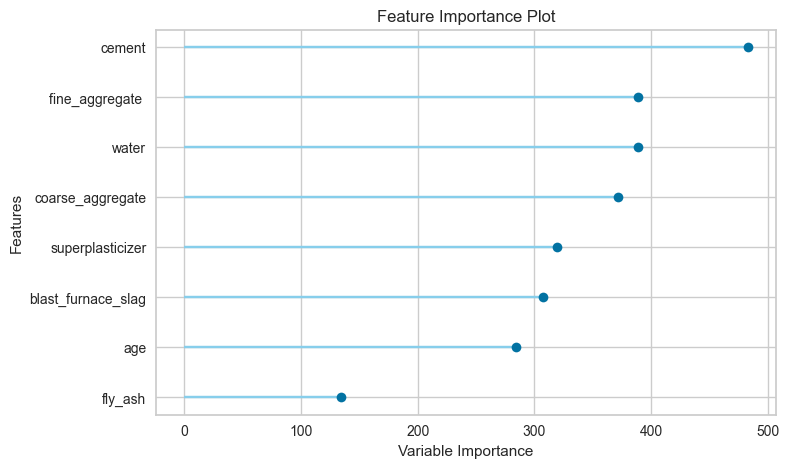

In [5]:
# 4단계: 시각적 분석 (오차율 그래프, 어떤 성분이 중요했는지 순위 보기)
plot_model(tuned_model, plot='feature')

In [6]:
# 5단계: 예측 (실전 데이터 대입해서 결괏값 확인하기)
predictions = predict_model(tuned_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,3.0880,22.9008,4.7855,0.9132,0.1428,0.1059
